# Modele XGboost

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.neural_network import MLPRegressor


In [25]:
dataframe = pd.read_csv('dataset_final.csv')
dataframe['remainder__Emissions CO2 (g/km)']

0        196.0
1        221.0
2        136.0
3        255.0
4        244.0
         ...  
92587    322.0
92588    317.0
92589    317.0
92590    322.0
92591    317.0
Name: remainder__Emissions CO2 (g/km), Length: 92592, dtype: float64

Supression des lignes dupliquées

In [26]:
print(dataframe.duplicated().sum())
dataframe.drop_duplicates(inplace=True)
print(dataframe.duplicated().sum())

44733
0


In [27]:

if 'Unnamed: 0' in dataframe.columns:
    dataframe.drop('Unnamed: 0', axis=1, inplace=True)

X = dataframe.drop('remainder__Emissions CO2 (g/km)',axis=1)
y = dataframe['remainder__Emissions CO2 (g/km)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Vérification des tailles
print(f"Entraînement : {X_train.shape[0]} lignes")
print(f"Test         : {X_test.shape[0]} lignes")

Entraînement : 33501 lignes
Test         : 14358 lignes


In [28]:
for col in X.columns:
    print(col)


ohe__Marque_ACURA
ohe__Marque_ALFA ROMEO
ohe__Marque_ALFA-ROMEO
ohe__Marque_ASTON MARTIN
ohe__Marque_AUDI
ohe__Marque_BENTLEY
ohe__Marque_BMW
ohe__Marque_BUGATTI
ohe__Marque_BUICK
ohe__Marque_CADILLAC
ohe__Marque_CARBODIES
ohe__Marque_CHEVROLET
ohe__Marque_CHRYSLER
ohe__Marque_CITROEN
ohe__Marque_DACIA
ohe__Marque_DAEWOO
ohe__Marque_DAIHATSU
ohe__Marque_DAIMLER
ohe__Marque_DODGE
ohe__Marque_FERRARI
ohe__Marque_FIAT
ohe__Marque_FORD
ohe__Marque_GENESIS
ohe__Marque_GMC
ohe__Marque_HOMMELL
ohe__Marque_HONDA
ohe__Marque_HYUNDAI
ohe__Marque_INFINITI
ohe__Marque_ISUZU
ohe__Marque_IVECO
ohe__Marque_JAGUAR
ohe__Marque_JEEP
ohe__Marque_KIA
ohe__Marque_LADA
ohe__Marque_LADA-VAZ
ohe__Marque_LAMBORGHINI
ohe__Marque_LANCIA
ohe__Marque_LAND ROVER
ohe__Marque_LEXUS
ohe__Marque_LINCOLN
ohe__Marque_LOTUS
ohe__Marque_LTI
ohe__Marque_LTI VEHICLES
ohe__Marque_MASERATI
ohe__Marque_MAYBACH
ohe__Marque_MAZDA
ohe__Marque_MEGA
ohe__Marque_MERCEDES
ohe__Marque_MERCEDES AMG
ohe__Marque_MERCEDES-BENZ
ohe__Marque_

In [29]:
# Entrainement 
model_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    tree_method="hist" 
)

model_xgb.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [30]:
y_train_pred_xg = model_xgb.predict(X_train)
y_test_pred_xg = model_xgb.predict(X_test)

In [31]:
train_mse_xg = mean_squared_error(y_train, y_train_pred_xg)
test_mse_xg = mean_squared_error(y_test, y_test_pred_xg)

train_rmse_xg = np.sqrt(train_mse_xg)
test_rmse_xg = np.sqrt(test_mse_xg)

train_mae_xg = mean_absolute_error(y_train, y_train_pred_xg)
test_mae_xg = mean_absolute_error(y_test, y_test_pred_xg)

train_r2_xg = r2_score(y_train, y_train_pred_xg)
test_r2_xg = r2_score(y_test, y_test_pred_xg)

performance_table = pd.DataFrame({
    'Métrique': ['MSE', 'RMSE', 'MAE', 'R²'],
    'Ensemble d\'entraînement': [train_mse_xg, train_rmse_xg, train_mae_xg, train_r2_xg],
    'Ensemble de test': [test_mse_xg, test_rmse_xg, test_mae_xg, test_r2_xg]
})

print(performance_table)


  Métrique  Ensemble d'entraînement  Ensemble de test
0      MSE                 1.097755          2.928530
1     RMSE                 1.047738          1.711295
2      MAE                 0.670577          0.885884
3       R²                 0.999662          0.999122


In [32]:
erreurs = pd.DataFrame({
    "Réel": y_test,
    "Pred": y_test_pred_xg,
    "Erreur": abs(y_test - y_test_pred_xg)
}).sort_values("Erreur", ascending=False)

erreurs.head(10)


,Réel,Pred,Erreur
92529,183.0,225.822998,42.822998
349,488.0,450.486389,37.513611
73479,215.0,243.759827,28.759827
2663,465.0,438.613403,26.386597
69137,449.0,473.655792,24.655792
65998,369.0,393.062714,24.062714
2434,465.0,441.017334,23.982666
65997,369.0,390.883240,21.883240
74215,178.0,199.060715,21.060715
73508,244.0,223.092377,20.907623


# Modele Random Forest

In [33]:
model_random_forest = RandomForestRegressor(n_estimators=500,criterion='friedman_mse',max_depth=None,min_samples_split=4,min_samples_leaf=2,bootstrap=True,max_features='sqrt')
model_random_forest.fit(X_train,y_train)

,n_estimators,500
,criterion,'friedman_mse'
,max_depth,None
,min_samples_split,4
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
y_train_pred_rf = model_random_forest.predict(X_train)
y_test_pred_rf = model_random_forest.predict(X_test)

# 2. Calculer les métriques d'erreur
train_mse_rf = mean_squared_error(y_train, y_train_pred_rf)
test_mse_rf = mean_squared_error(y_test, y_test_pred_rf)

train_rmse_rf = np.sqrt(train_mse_rf)
test_rmse_rf = np.sqrt(test_mse_rf)

train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)

train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

performance_table = pd.DataFrame({
    'Métrique': ['MSE', 'RMSE', 'MAE', 'R²'],
    'Ensemble d\'entraînement': [train_mse_rf, train_rmse_rf, train_mae_rf, train_r2_rf],
    'Ensemble de test': [test_mse_rf, test_rmse_rf, test_mae_rf, test_r2_rf]
})

print(performance_table)


  Métrique  Ensemble d'entraînement  Ensemble de test
0      MSE                10.995524         18.670296
1     RMSE                 3.315950          4.320914
2      MAE                 1.687796          2.097505
3       R²                 0.996614          0.994403


In [35]:
erreurs = pd.DataFrame({
    "Réel": y_test,
    "Pred": y_test_pred_rf,
    "Erreur": abs(y_test - y_test_pred_rf)
}).sort_values("Erreur", ascending=False)

erreurs.head(10)

,Réel,Pred,Erreur
8460,13.0,106.388788,93.388788
349,488.0,396.807597,91.192403
7583,572.0,489.893252,82.106748
47972,71.0,150.512931,79.512931
47918,72.0,144.079503,72.079503
69136,570.0,503.735755,66.264245
5511,465.0,401.539342,63.460658
66066,558.0,501.672486,56.327514
92529,183.0,237.384600,54.384600
3331,450.0,398.765064,51.234936


# Modele Decision Tree

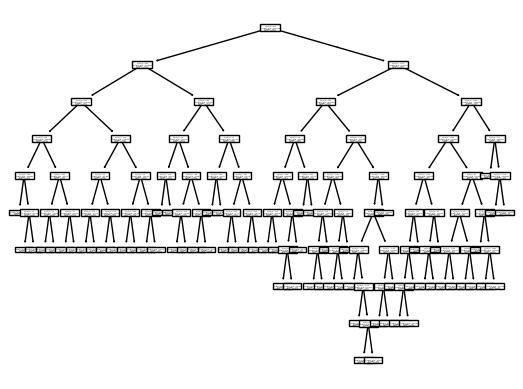

In [36]:
model_tree = DecisionTreeRegressor(criterion='friedman_mse',max_depth=11,splitter='best',min_samples_leaf=50,max_leaf_nodes=65,min_samples_split=100,ccp_alpha=0)
model_tree.fit(X_train,y_train)
tree.plot_tree(model_tree)
plt.show()

In [37]:
y_train_pred_t = model_tree.predict(X_train)
y_test_pred_t = model_tree.predict(X_test)

# 2. Calculer les métriques d'erreur
train_mse_t = mean_squared_error(y_train, y_train_pred_t)
test_mse_t = mean_squared_error(y_test, y_test_pred_t)

train_rmse_t = np.sqrt(train_mse_t)
test_rmse_t = np.sqrt(test_mse_t)

train_mae_t = mean_absolute_error(y_train, y_train_pred_t)
test_mae_t = mean_absolute_error(y_test, y_test_pred_t)

train_r2_t = r2_score(y_train, y_train_pred_t)
test_r2_t = r2_score(y_test, y_test_pred_t)

performance_table = pd.DataFrame({
    'Métrique': ['MSE', 'RMSE', 'MAE', 'R²'],
    'Ensemble d\'entraînement': [train_mse_t, train_rmse_t, train_mae_t, train_r2_t],
    'Ensemble de test': [test_mse_t, test_rmse_t, test_mae_t, test_r2_t]
})

print(performance_table)


  Métrique  Ensemble d'entraînement  Ensemble de test
0      MSE                55.133812         63.264884
1     RMSE                 7.425215          7.953923
2      MAE                 3.795241          3.909742
3       R²                 0.983023          0.981035


In [38]:
erreurs = pd.DataFrame({
    "Réel": y_test,
    "Pred": y_test_pred_t,
    "Erreur": abs(y_test - y_test_pred_t)
}).sort_values("Erreur", ascending=False)

erreurs.head(10)

,Réel,Pred,Erreur
76146,283.0,399.375000,116.375000
76147,289.0,399.375000,110.375000
9864,244.0,349.588496,105.588496
349,488.0,389.688742,98.311258
6045,487.0,389.688742,97.311258
3575,192.0,282.717001,90.717001
318,195.0,282.717001,87.717001
5743,218.0,305.444444,87.444444
4957,218.0,305.444444,87.444444
91260,159.0,246.183024,87.183024


# Modele MLP

In [39]:
model_mlp = MLPRegressor(
    hidden_layer_sizes=(32, 16),   # réseau léger
    activation='relu',
    solver='adam',
    max_iter=200,                  # réduit pour la vitesse
    early_stopping=True,           # arrêt automatique
    n_iter_no_change=10,
    learning_rate_init=0.001,
    random_state=42
)
model_mlp.fit(X_train, y_train)


,loss,'squared_error'
,hidden_layer_sizes,"(32, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True


In [40]:
y_train_pred_mlp = model_mlp.predict(X_train)
y_test_pred_mlp = model_mlp.predict(X_test)

# 2. Calculer les métriques d'erreur
train_mse_mlp = mean_squared_error(y_train, y_train_pred_mlp)
test_mse_mlp = mean_squared_error(y_test, y_test_pred_mlp)

train_rmse_mlp = np.sqrt(train_mse_mlp)
test_rmse_mlp = np.sqrt(test_mse_mlp)

train_mae_mlp = mean_absolute_error(y_train, y_train_pred_mlp)
test_mae_mlp = mean_absolute_error(y_test, y_test_pred_mlp)

train_r2_mlp = r2_score(y_train, y_train_pred_mlp)
test_r2_mlp = r2_score(y_test, y_test_pred_mlp)

performance_table = pd.DataFrame({
    'Métrique': ['MSE', 'RMSE', 'MAE', 'R²'],
    'Ensemble d\'entraînement': [train_mse_mlp, train_rmse_mlp, train_mae_mlp, train_r2_mlp],
    'Ensemble de test': [test_mse_mlp, test_rmse_mlp, test_mae_mlp, test_r2_mlp]
})

print(performance_table)


  Métrique  Ensemble d'entraînement  Ensemble de test
0      MSE                13.765967         14.521606
1     RMSE                 3.710252          3.810722
2      MAE                 2.261725          2.302259
3       R²                 0.995761          0.995647


In [41]:
erreurs = pd.DataFrame({
    "Réel": y_test,
    "Pred": y_test_pred_mlp,
    "Erreur": abs(y_test - y_test_pred_mlp)
}).sort_values("Erreur", ascending=False)

erreurs.head(10)

,Réel,Pred,Erreur
73479,215.0,310.343720,95.343720
8460,13.0,98.461522,85.461522
9864,244.0,318.355328,74.355328
47918,72.0,128.492203,56.492203
92529,183.0,235.887123,52.887123
69137,449.0,500.957583,51.957583
76147,289.0,335.289740,46.289740
76146,283.0,326.055177,43.055177
47972,71.0,111.777228,40.777228
228,413.0,452.300213,39.300213


# Evaluation pour les trois modeles

In [42]:

resultats = pd.DataFrame({
    "Modèle": [
        "model_xgb",
        "model_random_forest",
        "model_tree",
        "model_mlp"
    ],
    "RMSE Test": [
        test_rmse_xg,
        test_rmse_rf,
        test_rmse_t,
        test_rmse_mlp
    ],
    "R² Test": [
        test_r2_xg,
        test_r2_rf,
        test_r2_t,
        test_r2_mlp
    ]
})

resultats = resultats.sort_values("RMSE Test", ascending=True).reset_index(drop=True)

print("\n📊 Résultats comparatifs :\n")
print(resultats)



📊 Résultats comparatifs :

                Modèle  RMSE Test   R² Test
0            model_xgb   1.711295  0.999122
1            model_mlp   3.810722  0.995647
2  model_random_forest   4.320914  0.994403
3           model_tree   7.953923  0.981035
